In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torch.utils.data.dataset
from torch.utils.tensorboard import SummaryWriter
import random
import numpy as np
import seaborn as sns
import copy
import matplotlib.pyplot as plt
import kagglehub
from PIL import Image, ImageFilter, ImageDraw
from google.colab import drive
from torch.utils.data import Dataset, DataLoader, Subset
from tqdm import tqdm
from sklearn.metrics import confusion_matrix

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data_dir = kagglehub.dataset_download("ankit1743/skyview-an-aerial-landscape-dataset")
data_dir += "/Aerial_Landscapes"

In [4]:
class TransformedSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        X, y = self.subset[index]
        if self.transform:
            X = self.transform(X)
        return X, y

    def __len__(self):
        return len(self.subset)

In [5]:
def add_noise(image, mean=0, std=25):
    np_img = np.array(image).astype(np.float32)
    noise = np.random.normal(mean, std, np_img.shape)
    noisy_img = np.clip(np_img + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(noisy_img)

def add_blur(image, radius=2):
    return image.filter(ImageFilter.GaussianBlur(radius))

def add_occlusion(image, occ_size_ratio=0.2):
    image = image.copy()  # Work on a copy to avoid modifying the original
    width, height = image.size
    occ_size = int(min(width, height) * occ_size_ratio)
    # Randomly choose top-left corner for the occlusion rectangle
    top_left_x = random.randint(0, width - occ_size)
    top_left_y = random.randint(0, height - occ_size)

    draw = ImageDraw.Draw(image)
    # Draw a black rectangle for occlusion; you can change the fill color if needed.
    draw.rectangle([top_left_x, top_left_y, top_left_x + occ_size, top_left_y + occ_size], fill=(0, 0, 0))
    return image

def reduction_transform(image):
    # If the image is not a PIL image, assume it is already a tensor and convert it to PIL
    if not isinstance(image, Image.Image):
        image = TF.to_pil_image(image)
    image = add_noise(image)
    image = add_blur(image)
    image = add_occlusion(image)
    return image

In [6]:
class SEBlock(nn.Module):
    def __init__(self, in_channels, reduction=4):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=True),
            nn.ReLU(inplace=True),
            nn.Linear(in_channels // reduction, in_channels, bias=True),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y

class MBConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, expand_ratio, kernel_size=3, stride=1, reduction=4):
        super().__init__()
        hidden_dim = in_channels * expand_ratio
        self.use_res_connect = (stride == 1 and in_channels == out_channels)

        layers = []
        # Expansion phase (if expand_ratio != 1)
        if expand_ratio != 1:
            layers.extend([
                nn.Conv2d(in_channels, hidden_dim, kernel_size=1, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.SiLU(inplace=True)
            ])

        # Depthwise convolution
        layers.extend([
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=kernel_size, stride=stride,
                      padding=kernel_size // 2, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.SiLU(inplace=True)
        ])

        # Squeeze and Excitation
        layers.append(SEBlock(hidden_dim, reduction=reduction))

        # Projection phase
        layers.extend([
            nn.Conv2d(hidden_dim, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels)
        ])

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_res_connect:
            return x + self.block(x)
        else:
            return self.block(x)

class EfficientNet(nn.Module):
    def __init__(self, num_classes=15):
        super().__init__()
        # Stem: initial convolution layer
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.SiLU(inplace=True)
        )

        # Define a series of MBConv blocks.
        # The configuration list follows: [in_channels, out_channels, num_blocks, expand_ratio, kernel_size, stride]
        config = [
            [32, 16, 1, 1, 3, 1],
            [16, 24, 2, 6, 3, 2],
            [24, 40, 2, 6, 5, 2],
            [40, 80, 3, 6, 3, 2],
            [80, 112, 3, 6, 5, 1],
            [112, 192, 4, 6, 5, 2],
            [192, 320, 1, 6, 3, 1]
        ]

        blocks = []
        for in_channels, out_channels, num_blocks, expand_ratio, kernel_size, stride in config:
            # First block in each group may have a stride > 1 for downsampling.
            blocks.append(MBConvBlock(in_channels, out_channels, expand_ratio, kernel_size, stride))
            for _ in range(1, num_blocks):
                blocks.append(MBConvBlock(out_channels, out_channels, expand_ratio, kernel_size, stride=1))

        self.blocks = nn.Sequential(*blocks)

        # Head: Final convolution, pooling and classifier
        self.head = nn.Sequential(
            nn.Conv2d(320, 1280, kernel_size=1, bias=False),
            nn.BatchNorm2d(1280),
            nn.SiLU(inplace=True)
        )

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.2)
        self.classifier = nn.Linear(1280, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        x = self.head(x)
        x = self.pool(x).view(x.size(0), -1)
        x = self.dropout(x)
        x = self.classifier(x)
        return x

In [7]:
class RandomMask(nn.Module):
    def __init__(self, num_blocks=3, block_size=50, p=0.5):
        super().__init__()
        self.num_blocks = num_blocks
        self.block_size = block_size
        self.p = p

    def forward(self, img):
        if random.random() < self.p:
            # 获取Tensor格式的尺寸
            c, h, w = img.shape

            for _ in range(self.num_blocks):
                # random block position
                x = random.randint(0, h - self.block_size)
                y = random.randint(0, w - self.block_size)

                # random mask type
                mask_type = random.choice([0, 1, 2])

                if mask_type == 0:  # gray block
                    img[:, x:x+self.block_size, y:y+self.block_size] = 0.5 # 0.5是灰色
                elif mask_type == 1:  # random noise
                    noise = torch.rand_like(img[:, x:x+self.block_size, y:y+self.block_size])
                    img[:, x:x+self.block_size, y:y+self.block_size] = noise
                else:
                    pass
        return img

In [8]:
dataset = datasets.ImageFolder(root=data_dir, transform=None)
dataset_size = len(dataset)

# Get the total number of classes
num_classes = len(dataset.classes)

# Prepare index lists for train, validation, and test datasets
train_idx = []
val_idx = []
test_idx = []

# Convert the targets list to a NumPy array for easy indexing
targets = np.array(dataset.targets)

# Loop through each class and split indices
for cls in range(num_classes):
    # Find the indices for the given class
    cls_indices = np.where(targets == cls)[0]

    # Shuffle indices to randomize sample selection
    np.random.shuffle(cls_indices)

    n_total = len(cls_indices)
    n_train = int(0.7 * n_total)
    n_val = int(0.1 * n_total)

    # Use the rest for test
    n_test = n_total - n_train - n_val

    # Append the split indices to the respective lists
    train_idx.extend(cls_indices[:n_train])
    val_idx.extend(cls_indices[n_train:n_train+n_val])
    test_idx.extend(cls_indices[n_train+n_val:])

# Create Subset datasets using the indices generated above
train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)

train_size = len(train_dataset)
val_size = len(val_dataset)
test_size = len(test_dataset)

# Output sizes
print("Total dataset size:", dataset_size)
print("Imbalanced Training set size:", train_size)
print("Validation set size:", val_size)
print("Test set size:", test_size)

Total dataset size: 12000
Imbalanced Training set size: 8400
Validation set size: 1200
Test set size: 2400


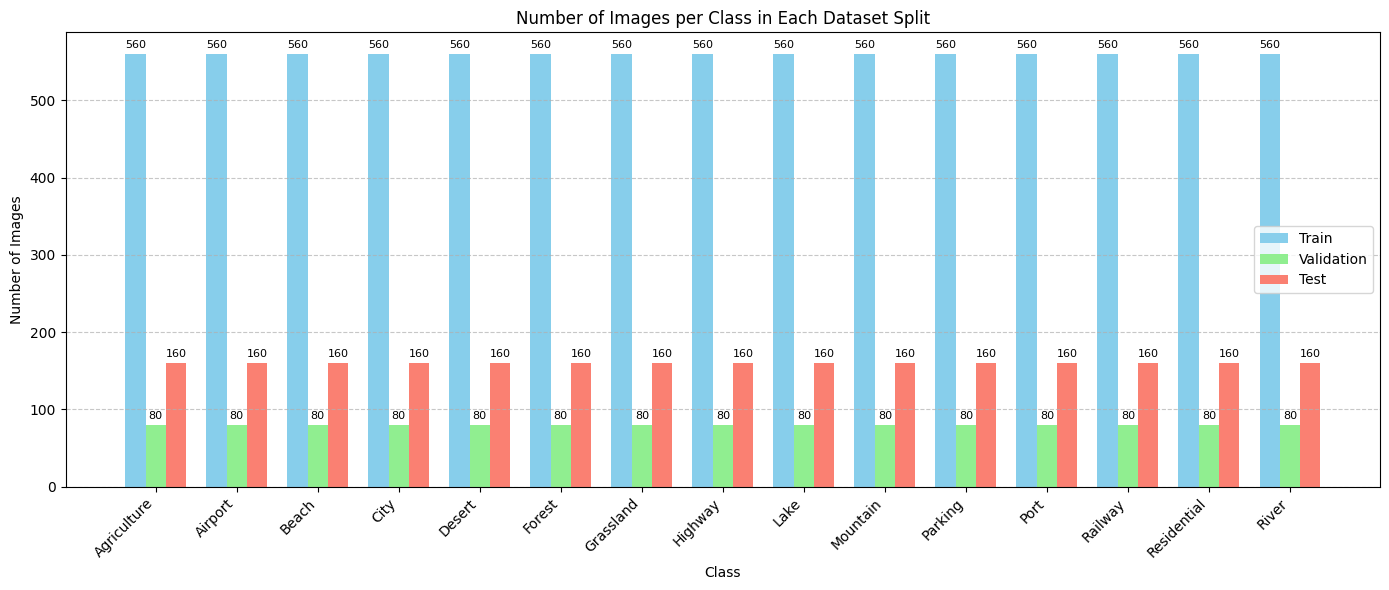

In [9]:
# Check the number of images per class in each split.
def count_per_class(subset, num_classes):
    # Retrieve indices and corresponding targets
    counts = np.zeros(num_classes, dtype=int)
    for idx in subset.indices:
        label = targets[idx]
        counts[label] += 1
    return counts

# Count per class
train_counts = count_per_class(train_dataset, num_classes)
val_counts = count_per_class(val_dataset, num_classes)
test_counts = count_per_class(test_dataset, num_classes)

# Plotting
bar_width = 0.25
x = np.arange(len(dataset.classes))

plt.figure(figsize=(14, 6))
bars1 = plt.bar(x - bar_width, train_counts, width=bar_width, label='Train', color='skyblue')
bars2 = plt.bar(x, val_counts, width=bar_width, label='Validation', color='lightgreen')
bars3 = plt.bar(x + bar_width, test_counts, width=bar_width, label='Test', color='salmon')

# Add labels on top of each bar
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height + 5, str(height),
                 ha='center', va='bottom', fontsize=8)

plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Number of Images per Class in Each Dataset Split')
plt.xticks(x, dataset.classes, rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [10]:
test_transforms = transforms.Compose([
    reduction_transform,     # Apply custom reductions (noise, blur, occlusion)
    transforms.RandomResizedCrop(256),
    transforms.ToTensor(),   # Convert image to a tensor for training
    transforms.Normalize([0.485, 0.456, 0.406],
                        [0.229, 0.224, 0.225])
])

generic_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
               std=[0.229, 0.224, 0.225])
])

In [11]:
# Apply the transforms to the datasets
train_dataset = TransformedSubset(train_dataset, generic_transform)
val_dataset = TransformedSubset(val_dataset, generic_transform)
test_dataset = TransformedSubset(test_dataset, generic_transform)
reduction_test = TransformedSubset(test_dataset, test_transforms)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4)
reduction_loader = DataLoader(reduction_test, batch_size=64, shuffle=False, num_workers=4)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EfficientNet(num_classes=15).to(device)
criterion = nn.CrossEntropyLoss()
num_epochs = 100
# optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
total_params = sum(p.numel() for p in model.parameters())

print(f"Total number of parameters: {total_params}")

Total number of parameters: 7162063


In [12]:
best_models = []  # Stores (validation accuracy, epoch, model_state_dict)

# TensorBoard writer
writer = SummaryWriter(log_dir=f"/content/drive/MyDrive/Colab Notebooks/EfficientNet/EfficientNet_model_logs")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    best_accuracy = 0.0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch")

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        progress_bar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / train_size

    # Validation phase
    model.eval()
    correct = 0
    total = 0
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)

    val_loss /= val_size
    accuracy = 100 * correct / total

    writer.add_scalar("Accuracy/Validation", accuracy, epoch)
    writer.add_scalar("Loss/Training", epoch_loss, epoch)
    writer.add_scalar("Loss/Validation", val_loss, epoch)

    print(f"Validation: Accuracy: {accuracy:.2f}%, Loss: {val_loss:.2f}")

    # Save the best 5 models based on validation accuracy
    if len(best_models) < 5:
        best_models.append((accuracy, epoch, copy.deepcopy(model.state_dict())))  # Store a deep copy of the model state
    else:
        # Find the model with the lowest validation accuracy
        min_idx = min(range(len(best_models)), key=lambda i: best_models[i][0])  # Get index of the worst model
        if accuracy > best_models[min_idx][0]:  # Replace only if the current model is better
           best_models[min_idx] = (accuracy, epoch, copy.deepcopy(model.state_dict()))  # Corrected replacement
writer.close()


Epoch 1/100: 100%|██████████| 132/132 [00:19<00:00,  6.81batch/s, loss=1.4]


Validation: Accuracy: 48.08%, Loss: 1.48


Epoch 2/100: 100%|██████████| 132/132 [00:14<00:00,  9.36batch/s, loss=0.556]


Validation: Accuracy: 66.17%, Loss: 1.03


Epoch 3/100: 100%|██████████| 132/132 [00:14<00:00,  9.40batch/s, loss=0.8]


...

Validation: Accuracy: 81.42%, Loss: 0.99


Epoch 99/100: 100%|██████████| 132/132 [00:14<00:00,  9.18batch/s, loss=0.0311]


Validation: Accuracy: 80.00%, Loss: 1.03


Epoch 100/100: 100%|██████████| 132/132 [00:14<00:00,  9.21batch/s, loss=0.472]


Validation: Accuracy: 80.42%, Loss: 1.04


Model from Epoch 78 (Val Acc: 83.75%) -> Test Accuracy: 81.88%
Model from Epoch 77 (Val Acc: 83.17%) -> Test Accuracy: 83.71%
Model from Epoch 84 (Val Acc: 83.33%) -> Test Accuracy: 83.58%
Model from Epoch 79 (Val Acc: 83.42%) -> Test Accuracy: 83.04%
Model from Epoch 96 (Val Acc: 84.33%) -> Test Accuracy: 85.88%

Best Model on Test Set (based on test_loader): Epoch 96 with Test Accuracy: 85.88%

Final Evaluation with Best Model:
Test Loader Accuracy: 85.88%
Reduction Loader Accuracy: 10.96%


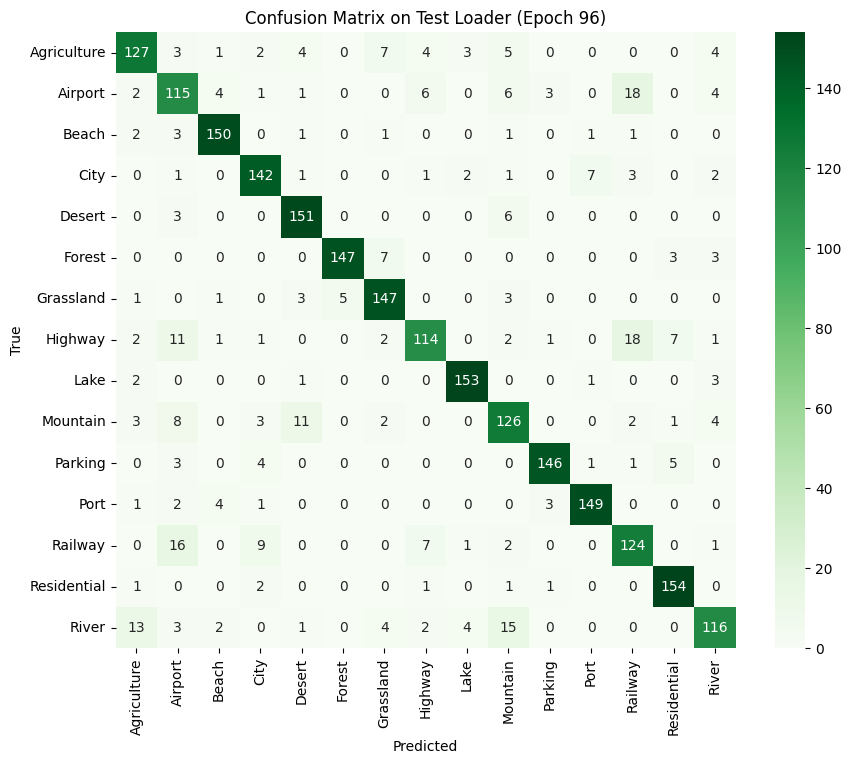

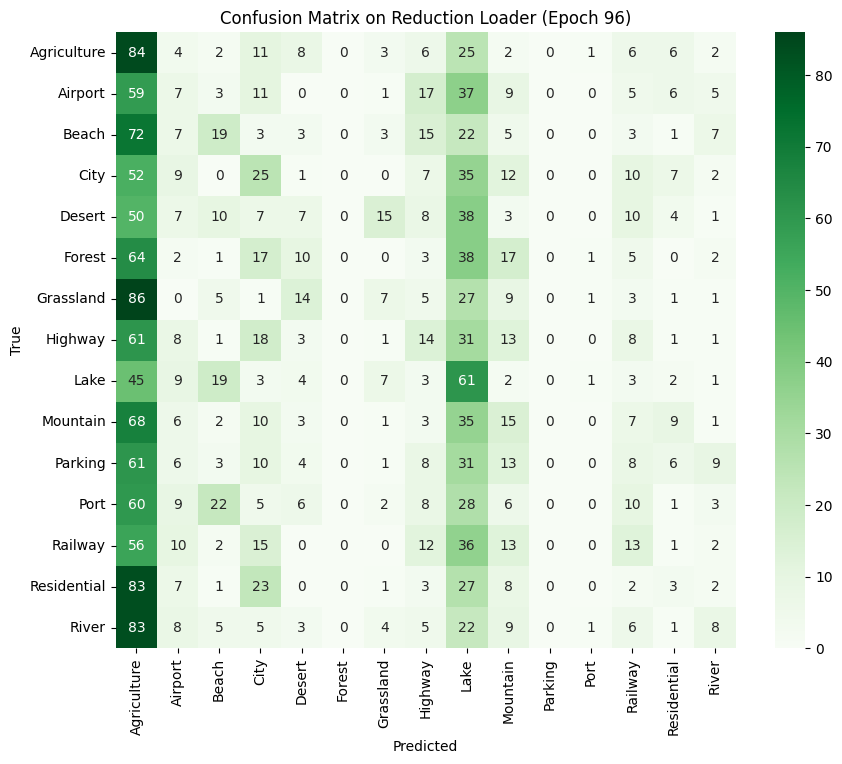

In [13]:
# First, compute the test accuracy for each model and select the best one
best_test_results = []

for val_acc, epoch, model_state in best_models:
    model.load_state_dict(model_state)  # Load model state from memory
    model.eval()

    correct_test = 0
    total_test = 0
    all_labels_test = []
    all_predictions_test = []

    # Evaluation on test_loader
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_labels_test.extend(labels.cpu().numpy())
            all_predictions_test.extend(predicted.cpu().numpy())
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_accuracy = 100 * correct_test / total_test
    print(f"Model from Epoch {epoch+1} (Val Acc: {val_acc:.2f}%) -> Test Accuracy: {test_accuracy:.2f}%")

    # You can store additional information if you plan on comparing models by reduction_loader as well
    best_test_results.append((test_accuracy, epoch, model_state, all_labels_test, all_predictions_test))

# Find the model with the highest test accuracy (based on test_loader)
best_test_results.sort(key=lambda x: x[0], reverse=True)
best_model_test = best_test_results[0]
best_test_acc, best_epoch, best_model_state, best_labels, best_predictions = best_model_test

print(f"\nBest Model on Test Set (based on test_loader): Epoch {best_epoch+1} with Test Accuracy: {best_test_acc:.2f}%")

# Now load the best model once again so that its evaluation is done consistently on both loaders
model.load_state_dict(best_model_state)
model.eval()

# Helper evaluation function to evaluate a given data loader
def evaluate(loader):
    correct = 0
    total = 0
    all_labels = []
    all_predictions = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
    accuracy = 100 * correct / total
    return accuracy, all_labels, all_predictions

# Evaluate the best model on both test_loader and reduction_loader
test_accuracy, test_labels, test_predictions = evaluate(test_loader)
reduction_accuracy, reduction_labels, reduction_predictions = evaluate(reduction_loader)

print(f"\nFinal Evaluation with Best Model:")
print(f"Test Loader Accuracy: {test_accuracy:.2f}%")
print(f"Reduction Loader Accuracy: {reduction_accuracy:.2f}%")

# Display the confusion matrix for test_loader
cm_test = confusion_matrix(test_labels, test_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=dataset.classes, yticklabels=dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix on Test Loader (Epoch {best_epoch+1})')
plt.show()

# Display the confusion matrix for reduction_loader
cm_reduction = confusion_matrix(reduction_labels, reduction_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_reduction, annot=True, fmt='d', cmap='Greens',
            xticklabels=dataset.classes, yticklabels=dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix on Reduction Loader (Epoch {best_epoch+1})')
plt.show()

In [14]:
save_path = "/content/drive/MyDrive/Colab Notebooks/EfficientNet/EfficientNet_model.pth"  # Adjust the path as needed
torch.save(best_model_state, save_path)
print(f"Best model saved to: {save_path}")

Best model saved to: /content/drive/MyDrive/Colab Notebooks/EfficientNet/EfficientNet_model.pth
